E23CSEU1732

PIYUSH CHAUAHN

LAB 1

In [ ]:
!pip -q install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.0 MB/s eta 0:00:00


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

import wfdb

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
import pandas as pd

# UCI Cleveland Heart Disease Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names according to the UCI dataset
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

# Load dataset
df = pd.read_csv(
    url,
    names=columns,
    na_values="?"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
print("Dataset Information:\n")

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [ ]:
print("Dataset Information:\n")

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [ ]:
missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

Missing values in each column:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
print("Columns in the dataset:\n")

for column in df.columns:
    print(column)

Columns in the dataset:

age
sex
cp
trestbps
chol
fbs
restecg
thalach
exang
oldpeak
slope
ca
thal
target


Target distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


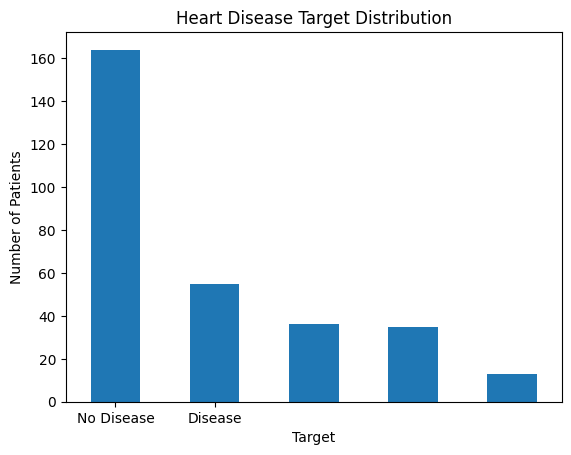

In [ ]:
print("Target distribution:")
print(df["target"].value_counts())

df["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"], rotation=0)
plt.show()

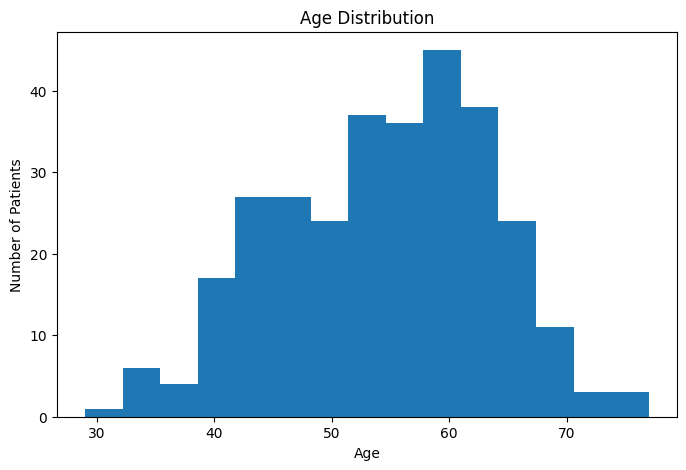

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

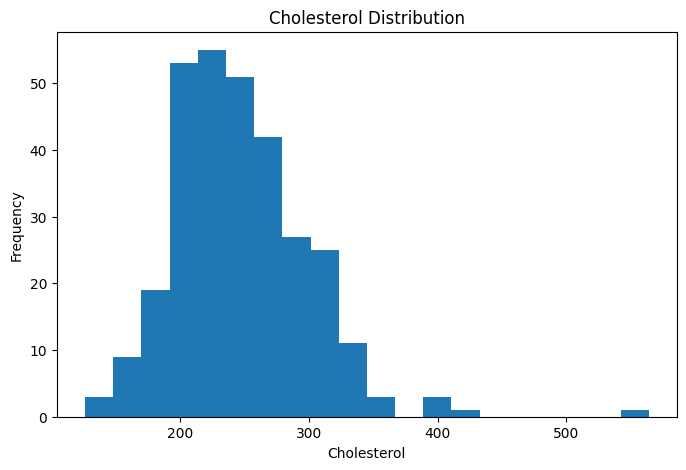

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["chol"], bins=20)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

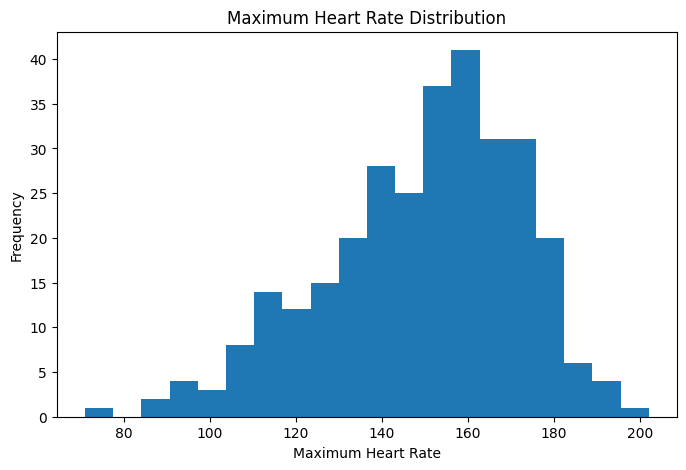

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["thalach"], bins=20)

plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Frequency")

plt.show()

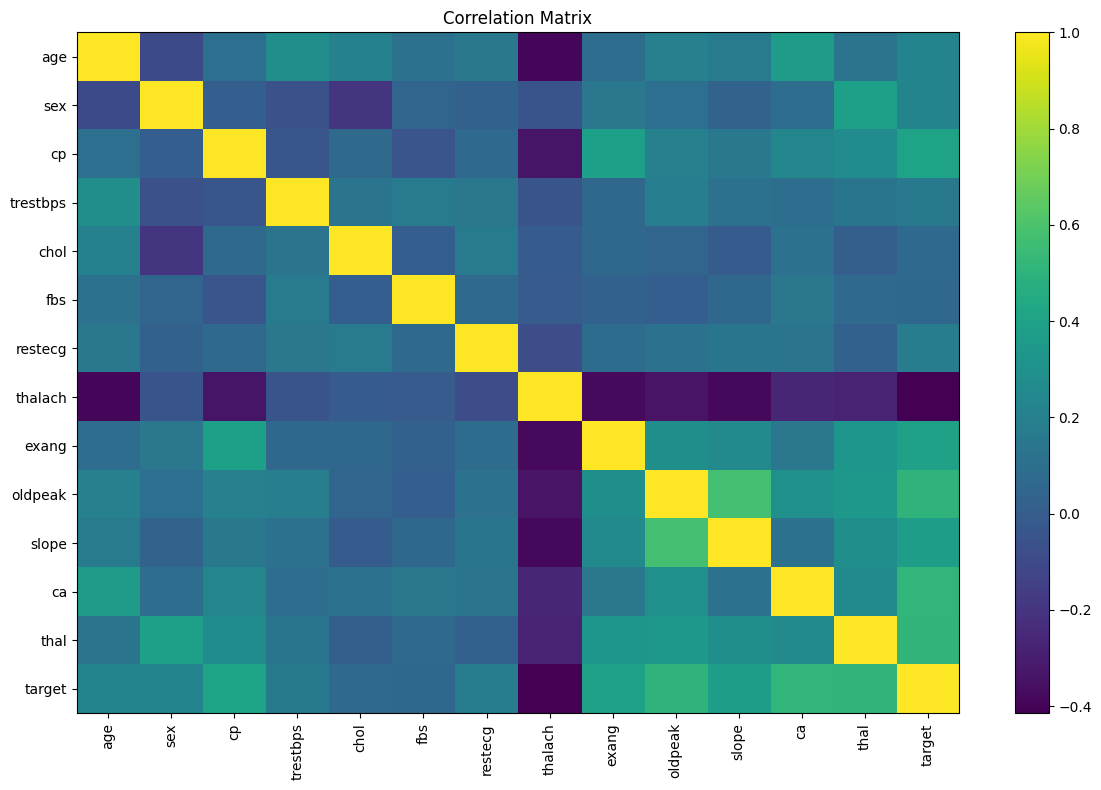

In [ ]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# Convert the original UCI target to binary
# 0 = No Heart Disease
# 1, 2, 3, 4 = Heart Disease

df["target"] = (df["target"] > 0).astype(int)

print("Target values:")
print(df["target"].unique())

print("\nTarget distribution:")
print(df["target"].value_counts())

Target values:
[0 1]

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (303, 13)
Target shape: (303,)


In [ ]:
# Make a copy so the original dataframe remains unchanged
model_df = df.copy()

# Check missing values before training
print("Missing values before preprocessing:")
print(model_df.isnull().sum())

# Remove rows containing missing values
model_df = model_df.dropna().reset_index(drop=True)

print("\nDataset shape after removing missing values:")
print(model_df.shape)

# Separate features and target
X = model_df.drop("target", axis=1)
y = model_df["target"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Missing values before preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Dataset shape after removing missing values:
(297, 14)

Features shape: (297, 13)
Target shape: (297,)

Training samples: 237
Testing samples: 60


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[0 0 0 0 1 0 1 0 0 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8333


In [ ]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.9487


In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[28  4]
 [ 6 22]]


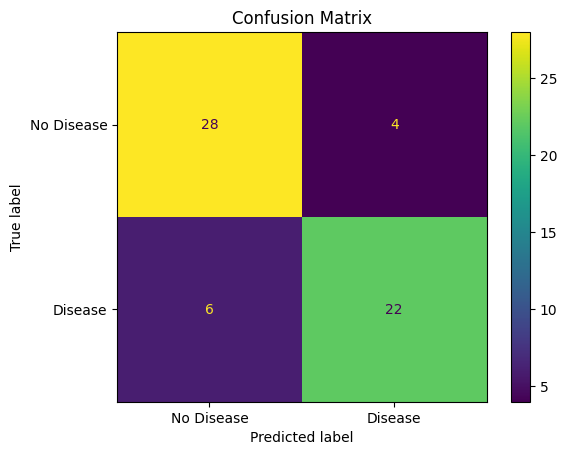

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Disease", "Disease"]
    )
)

              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



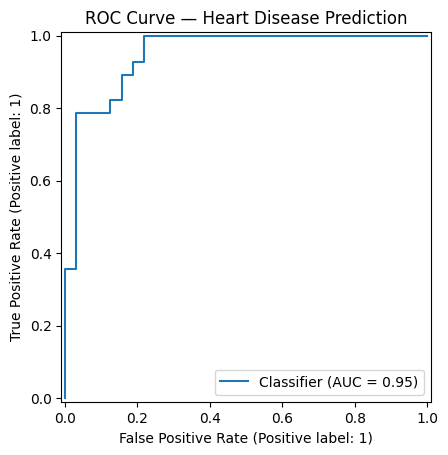

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("ROC Curve — Heart Disease Prediction")
plt.show()

In [ ]:
record_name = "100"

record = wfdb.rdrecord(
    record_name,
    pn_dir="mitdb"
)

annotation = wfdb.rdann(
    record_name,
    "atr",
    pn_dir="mitdb"
)

print("ECG record loaded successfully!")

print("Sampling frequency:", record.fs)
print("Number of samples:", record.sig_len)
print("Number of channels:", record.n_sig)

ECG record loaded successfully!
Sampling frequency: 360
Number of samples: 650000
Number of channels: 2


In [ ]:
print("Record name:", record.record_name)
print("Sampling frequency:", record.fs)
print("Signal length:", record.sig_len)
print("Signal names:", record.sig_name)
print("Units:", record.units)

Record name: 100
Sampling frequency: 360
Signal length: 650000
Signal names: ['MLII', 'V5']
Units: ['mV', 'mV']


In [ ]:
ecg_signal = record.p_signal[:, 0]

print("ECG signal extracted.")
print("Number of samples:", len(ecg_signal))

print("First 10 samples:")
print(ecg_signal[:10])

ECG signal extracted.
Number of samples: 650000
First 10 samples:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]


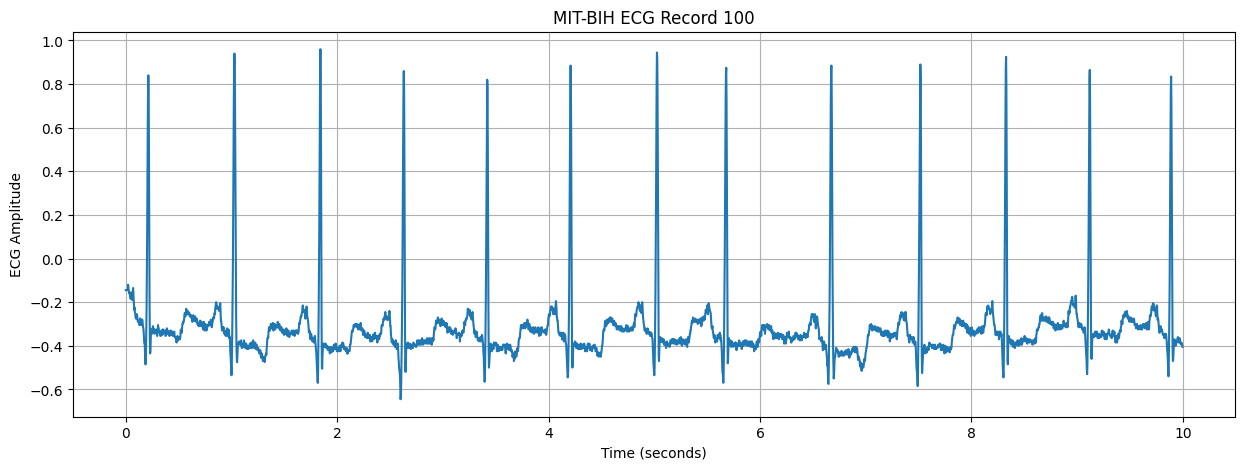

In [ ]:
sampling_frequency = record.fs

duration_seconds = 10

number_of_samples = int(
    duration_seconds * sampling_frequency
)

time = np.arange(number_of_samples) / sampling_frequency

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_signal[:number_of_samples]
)

plt.title("MIT-BIH ECG Record 100")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.grid(True)

plt.show()

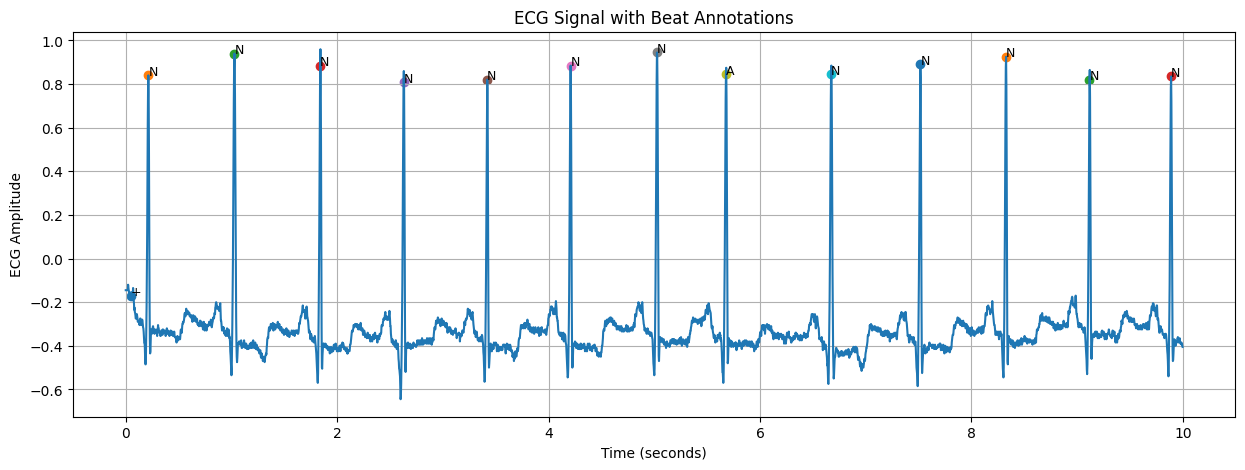

In [ ]:
start_sample = 0
end_sample = int(10 * record.fs)

annotation_samples = annotation.sample
annotation_symbols = annotation.symbol

plt.figure(figsize=(15, 5))

plt.plot(
    np.arange(start_sample, end_sample) / record.fs,
    ecg_signal[start_sample:end_sample]
)

for sample, symbol in zip(
    annotation_samples,
    annotation_symbols
):
    if start_sample <= sample < end_sample:

        x = sample / record.fs
        y = ecg_signal[sample]

        plt.scatter(x, y)

        plt.text(
            x,
            y,
            symbol,
            fontsize=9
        )

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.grid(True)
plt.show()

In [ ]:
beat_samples = annotation.sample

print("Number of annotations:", len(beat_samples))

print("First 20 annotation locations:")
print(beat_samples[:20])

Number of annotations: 2274
First 20 annotation locations:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


In [ ]:
rr_intervals_samples = np.diff(beat_samples)

rr_intervals_seconds = (
    rr_intervals_samples / record.fs
)

print("First 20 RR intervals:")
print(rr_intervals_seconds[:20])

First 20 RR intervals:
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444 0.81111111 0.78888889
 0.77222222 0.83888889 0.85555556 0.82222222 0.82777778 0.82222222
 0.79444444 0.79722222]


In [ ]:
mean_rr = np.mean(
    rr_intervals_seconds
)

average_heart_rate = 60 / mean_rr

print(
    "Average RR interval:",
    round(mean_rr, 3),
    "seconds"
)

print(
    "Estimated average heart rate:",
    round(average_heart_rate, 2),
    "BPM"
)

Average RR interval: 0.794 seconds
Estimated average heart rate: 75.54 BPM


In [ ]:
sdnn = np.std(
    rr_intervals_seconds
)

rmssd = np.sqrt(
    np.mean(
        np.diff(rr_intervals_seconds) ** 2
    )
)

print("Basic ECG / HRV statistics")
print("----------------------------")
print("Mean RR:", round(mean_rr, 4), "seconds")
print("SDNN:", round(sdnn, 4), "seconds")
print("RMSSD:", round(rmssd, 4), "seconds")

Basic ECG / HRV statistics
----------------------------
Mean RR: 0.7943 seconds
SDNN: 0.0506 seconds
RMSSD: 0.0647 seconds


In [ ]:
sdnn = np.std(
    rr_intervals_seconds
)

rmssd = np.sqrt(
    np.mean(
        np.diff(rr_intervals_seconds) ** 2
    )
)

print("Basic ECG / HRV statistics")
print("----------------------------")
print("Mean RR:", round(mean_rr, 4), "seconds")
print("SDNN:", round(sdnn, 4), "seconds")
print("RMSSD:", round(rmssd, 4), "seconds")

Basic ECG / HRV statistics
----------------------------
Mean RR: 0.7943 seconds
SDNN: 0.0506 seconds
RMSSD: 0.0647 seconds


In [ ]:
import re

# Clinical note
clinical_note = """
Patient is a 58 year old male.
The patient reports chest pain during physical activity.
Blood pressure is elevated.
The patient experiences shortness of breath and occasional fatigue.
No history of diabetes is reported.
The patient is advised to undergo further cardiac evaluation.
"""

# Convert to lowercase
clean_text = clinical_note.lower()

# Remove punctuation and numbers
clean_text = re.sub(
    r"[^a-z\s]",
    "",
    clean_text
)

print("Original Clinical Note:")
print(clinical_note)

print("\nCleaned Clinical Note:")
print(clean_text)

Original Clinical Note:

Patient is a 58 year old male.
The patient reports chest pain during physical activity.
Blood pressure is elevated.
The patient experiences shortness of breath and occasional fatigue.
No history of diabetes is reported.
The patient is advised to undergo further cardiac evaluation.


Cleaned Clinical Note:

patient is a  year old male
the patient reports chest pain during physical activity
blood pressure is elevated
the patient experiences shortness of breath and occasional fatigue
no history of diabetes is reported
the patient is advised to undergo further cardiac evaluation



In [ ]:
tokens = clean_text.split()

print("Number of tokens:", len(tokens))

print("\nTokens:")
print(tokens)

Number of tokens: 42

Tokens:
['patient', 'is', 'a', 'year', 'old', 'male', 'the', 'patient', 'reports', 'chest', 'pain', 'during', 'physical', 'activity', 'blood', 'pressure', 'is', 'elevated', 'the', 'patient', 'experiences', 'shortness', 'of', 'breath', 'and', 'occasional', 'fatigue', 'no', 'history', 'of', 'diabetes', 'is', 'reported', 'the', 'patient', 'is', 'advised', 'to', 'undergo', 'further', 'cardiac', 'evaluation']


In [ ]:
stopwords = {
    "the",
    "is",
    "a",
    "of",
    "and",
    "to",
    "during",
    "for",
    "no",
    "in",
    "on"
}

filtered_tokens = [
    word
    for word in tokens
    if word not in stopwords
]

print("Filtered tokens:")
print(filtered_tokens)

Filtered tokens:
['patient', 'year', 'old', 'male', 'patient', 'reports', 'chest', 'pain', 'physical', 'activity', 'blood', 'pressure', 'elevated', 'patient', 'experiences', 'shortness', 'breath', 'occasional', 'fatigue', 'history', 'diabetes', 'reported', 'patient', 'advised', 'undergo', 'further', 'cardiac', 'evaluation']


In [ ]:
from collections import Counter

# Count frequency of each word

word_frequency = Counter(filtered_tokens)

print("Word Frequencies:")
print()

for word, count in word_frequency.most_common():
    print(word, ":", count)

Word Frequencies:

patient : 4
year : 1
old : 1
male : 1
reports : 1
chest : 1
pain : 1
physical : 1
activity : 1
blood : 1
pressure : 1
elevated : 1
experiences : 1
shortness : 1
breath : 1
occasional : 1
fatigue : 1
history : 1
diabetes : 1
reported : 1
advised : 1
undergo : 1
further : 1
cardiac : 1
evaluation : 1


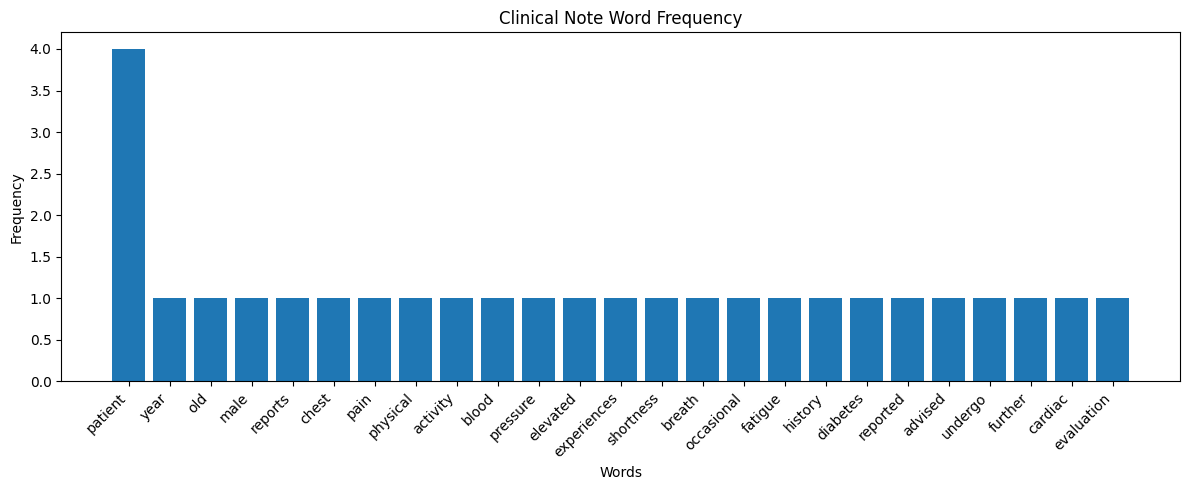

In [ ]:
words = [
    item[0]
    for item in word_frequency.most_common()
]

counts = [
    item[1]
    for item in word_frequency.most_common()
]

plt.figure(figsize=(12, 5))

plt.bar(words, counts)

plt.title("Clinical Note Word Frequency")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import numpy as np

print("Pillow and NumPy ready!")

Pillow and NumPy ready!


In [ ]:
# Create a simple synthetic grayscale medical-style image

image_array = np.zeros(
    (256, 256),
    dtype=np.uint8
)

center_x = 128
center_y = 128

for y in range(256):
    for x in range(256):

        distance = np.sqrt(
            (x - center_x) ** 2 +
            (y - center_y) ** 2
        )

        if distance < 90:
            image_array[y, x] = 180

        if distance < 60:
            image_array[y, x] = 100

        if distance < 30:
            image_array[y, x] = 220

medical_image = Image.fromarray(image_array)

print("Synthetic medical image created.")
print("Image size:", medical_image.size)
print("Image mode:", medical_image.mode)

Synthetic medical image created.
Image size: (256, 256)
Image mode: L


In [ ]:
print("Image format:", medical_image.format)
print("Image size:", medical_image.size)
print("Image mode:", medical_image.mode)

Image format: None
Image size: (256, 256)
Image mode: L


In [ ]:
new_size = (128, 128)

resized_image = medical_image.resize(
    new_size
)

print("Original size:", medical_image.size)
print("New size:", resized_image.size)

Original size: (256, 256)
New size: (128, 128)


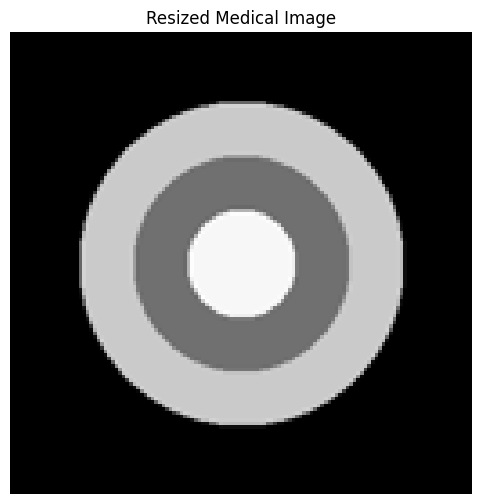

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(
    resized_image,
    cmap="gray"
)

plt.title("Resized Medical Image")
plt.axis("off")

plt.show()

In [ ]:
patient_record = {
    "patient_id": "P001",

    "tabular_data": {
        "age": 58,
        "sex": 1,
        "cholesterol": 230,
        "resting_bp": 140
    },

    "clinical_note": clinical_note,

    "ecg_record": "MIT-BIH Record 100",

    "medical_image": {
        "format": "Synthetic PNG-style image",
        "size": resized_image.size
    }
}

print("Patient record created successfully!")

Patient record created successfully!


In [ ]:
print("MULTIMODAL MEDICAL DATA")
print("=======================")

print("\nPatient ID:")
print(patient_record["patient_id"])

print("\nTabular Data:")

for key, value in patient_record["tabular_data"].items():
    print(f"{key}: {value}")

print("\nClinical Note:")
print(patient_record["clinical_note"])

print("\nECG:")
print(patient_record["ecg_record"])

print("\nMedical Image:")
print(patient_record["medical_image"])

MULTIMODAL MEDICAL DATA

Patient ID:
P001

Tabular Data:
age: 58
sex: 1
cholesterol: 230
resting_bp: 140

Clinical Note:

Patient is a 58 year old male.
The patient reports chest pain during physical activity.
Blood pressure is elevated.
The patient experiences shortness of breath and occasional fatigue.
No history of diabetes is reported.
The patient is advised to undergo further cardiac evaluation.


ECG:
MIT-BIH Record 100

Medical Image:
{'format': 'Synthetic PNG-style image', 'size': (128, 128)}


In [ ]:
def load_tabular_data(file_path):
    """
    Load tabular data from a CSV file.
    """

    data = pd.read_csv(file_path)

    print("Tabular data loaded successfully.")
    print("Shape:", data.shape)

    return data

In [ ]:
def load_text_data(file_path):
    """
    Load textual data from a text file.
    """

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as file:

        text = file.read()

    print("Text data loaded successfully.")
    print("Number of characters:", len(text))

    return text

In [ ]:
def load_image_data(file_path):
    """
    Load an image using Pillow.
    """

    image = Image.open(file_path)

    print("Image loaded successfully.")
    print("Image size:", image.size)
    print("Image mode:", image.mode)

    return image

In [ ]:
def load_ecg_signal(record_name):
    """
    Load an ECG signal and its annotations
    from the MIT-BIH Arrhythmia Database.
    """

    record = wfdb.rdrecord(
        record_name,
        pn_dir="mitdb"
    )

    annotation = wfdb.rdann(
        record_name,
        "atr",
        pn_dir="mitdb"
    )

    print("ECG signal loaded successfully.")
    print("Sampling frequency:", record.fs)
    print("Number of channels:", record.n_sig)
    print("Number of samples:", record.sig_len)

    return record, annotation

In [ ]:
test_record, test_annotation = load_ecg_signal("100")

ECG signal loaded successfully.
Sampling frequency: 360
Number of channels: 2
Number of samples: 650000


In [ ]:
summary = {
    "Tabular Data": "UCI Cleveland Heart Disease Dataset",
    "Textual Data": "Synthetic Clinical Note",
    "Image Data": "Synthetic Medical Image",
    "Signal Data": "MIT-BIH ECG Record 100",
    "Medical Data": "Combined Multimodal Patient Record"
}

print("DATA MODALITY SUMMARY")
print("=====================")

for modality, dataset in summary.items():
    print(f"{modality}: {dataset}")

DATA MODALITY SUMMARY
Tabular Data: UCI Cleveland Heart Disease Dataset
Textual Data: Synthetic Clinical Note
Image Data: Synthetic Medical Image
Signal Data: MIT-BIH ECG Record 100
Medical Data: Combined Multimodal Patient Record


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix
)

# Calculate predictions again
y_pred = model.predict(X_test)

# Probability of positive class
y_probability = model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("HEART DISEASE CLASSIFICATION RESULTS")
print("=====================================")

print("Accuracy :", round(accuracy, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nConfusion Matrix:")
print(cm)

HEART DISEASE CLASSIFICATION RESULTS
Accuracy : 0.8333
ROC-AUC  : 0.9487

Confusion Matrix:
[[28  4]
 [ 6 22]]


In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving resize-and-save-images-as-numpy-arrays-128x128.ipynb to resize-and-save-images-as-numpy-arrays-128x128 (1).ipynb
Uploaded files:
resize-and-save-images-as-numpy-arrays-128x128 (1).ipynb


In [ ]:
from PIL import Image

# Get the uploaded filename
image_filename = list(uploaded.keys())[0]

# Open image
medical_image = Image.open(image_filename)

print("Image loaded successfully!")
print("Filename:", image_filename)
print("Format:", medical_image.format)
print("Size:", medical_image.size)
print("Mode:", medical_image.mode)

UnidentifiedImageError: cannot identify image file 'resize-and-save-images-as-numpy-arrays-128x128 (1).ipynb'

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Create a 256 x 256 grayscale synthetic medical image
image_array = np.zeros((256, 256), dtype=np.uint8)

center_x = 128
center_y = 128

for y in range(256):
    for x in range(256):

        distance = np.sqrt(
            (x - center_x) ** 2 +
            (y - center_y) ** 2
        )

        if distance < 90:
            image_array[y, x] = 180

        if distance < 60:
            image_array[y, x] = 100

        if distance < 30:
            image_array[y, x] = 220

# Convert NumPy array to Pillow image
medical_image = Image.fromarray(image_array)

print("Synthetic medical image created successfully!")
print("Image size:", medical_image.size)
print("Image mode:", medical_image.mode)

Synthetic medical image created successfully!
Image size: (256, 256)
Image mode: L


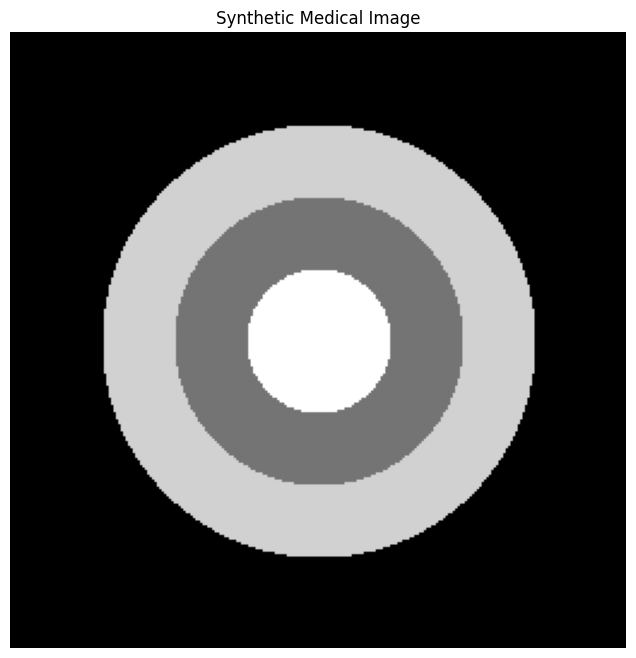

In [ ]:
plt.figure(figsize=(8, 8))

plt.imshow(
    medical_image,
    cmap="gray"
)

plt.title("Synthetic Medical Image")
plt.axis("off")

plt.show()

In [ ]:
print("IMAGE METADATA")
print("==============")

print("Format:", medical_image.format)
print("Mode:", medical_image.mode)
print("Width:", medical_image.width)
print("Height:", medical_image.height)
print("Number of Channels:", len(medical_image.getbands()))

print("\nImage Information:")
print(medical_image.info)

IMAGE METADATA
Format: None
Mode: L
Width: 256
Height: 256
Number of Channels: 1

Image Information:
{}


In [ ]:
image_array = np.array(medical_image)

print("Image converted to NumPy array successfully!")

print("Array Shape:", image_array.shape)
print("Data Type:", image_array.dtype)
print("Minimum Pixel Value:", image_array.min())
print("Maximum Pixel Value:", image_array.max())

Image converted to NumPy array successfully!
Array Shape: (256, 256)
Data Type: uint8
Minimum Pixel Value: 0
Maximum Pixel Value: 220


In [ ]:
resized_image = medical_image.resize(
    (224, 224)
)

print("Original Image Size:", medical_image.size)
print("Resized Image Size:", resized_image.size)

Original Image Size: (256, 256)
Resized Image Size: (224, 224)


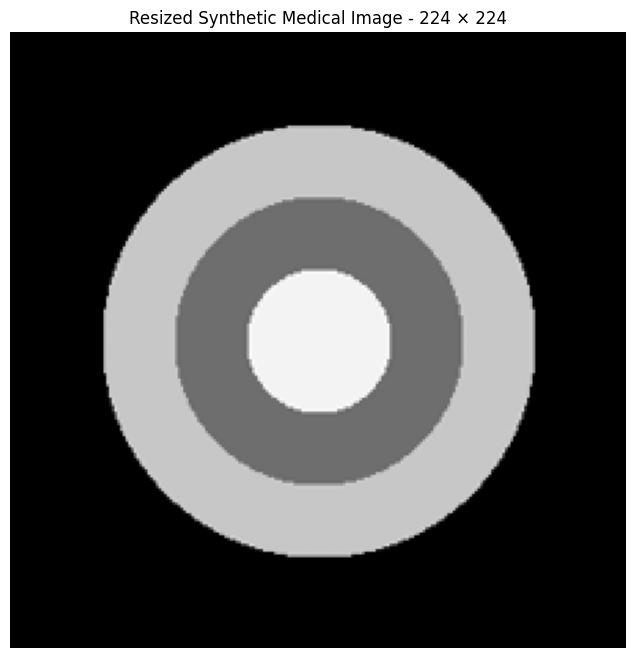

In [ ]:
plt.figure(figsize=(8, 8))

plt.imshow(
    resized_image,
    cmap="gray"
)

plt.title("Resized Synthetic Medical Image - 224 × 224")
plt.axis("off")

plt.show()

In [ ]:
synthetic_filename = "synthetic_medical_image.png"

medical_image.save(
    synthetic_filename
)

print("Synthetic image saved as:", synthetic_filename)

Synthetic image saved as: synthetic_medical_image.png


In [ ]:
reloaded_image = Image.open(
    synthetic_filename
)

print("Image reloaded successfully!")

print("\nIMAGE METADATA")
print("==============")

print("Format:", reloaded_image.format)
print("Mode:", reloaded_image.mode)
print("Width:", reloaded_image.width)
print("Height:", reloaded_image.height)
print("Number of Channels:", len(reloaded_image.getbands()))

print("\nAdditional Metadata:")
print(reloaded_image.info)

Image reloaded successfully!

IMAGE METADATA
Format: PNG
Mode: L
Width: 256
Height: 256
Number of Channels: 1

Additional Metadata:
{}


In [ ]:
print("IMAGE DATA DEMONSTRATION")
print("========================")

print("✓ Synthetic medical image created")
print("✓ Image loaded using Pillow")
print("✓ Image displayed")
print("✓ Image metadata extracted")
print("✓ Image converted to NumPy array")
print("✓ Image resized to 224 × 224")
print("✓ Image saved as PNG")
print("✓ Saved image reloaded and verified")

IMAGE DATA DEMONSTRATION
✓ Synthetic medical image created
✓ Image loaded using Pillow
✓ Image displayed
✓ Image metadata extracted
✓ Image converted to NumPy array
✓ Image resized to 224 × 224
✓ Image saved as PNG
✓ Saved image reloaded and verified
